# Intangible-Value — a quantitative teardown
### EDGAR fundamentals × perpetual-inventory intangibles × HAC inference × placebo

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats plain B/M%3F: Confirmed](https://img.shields.io/badge/Beats_plain_B%2FM%3F-Confirmed-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) — same seven beats, every claim carrying its standard error. We test Lev-Srivastava (2019): capitalise R&D (5-yr amortised knowledge capital) + 30%-of-SG&A (3-yr amortised organisation capital) into book, sort 40 large-caps on intangible-adjusted B/M, long the cheap tertile / short the expensive tertile, one reporting + one execution lag, monthly rebalance — and race it head-to-head against plain B/M.

> **Not investment advice.** Real data: SEC EDGAR companyfacts + yfinance monthly total returns, 40 large-caps, 2005-02 → 2026-05, as-of 2026-06-27. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship is named:** current-membership large-cap basket projected back; absolute levels are upper bounds (the bias is largely common to both legs).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from intangible_value import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return data.have_real(os.path.join(study, "_cache"))

HAVE_REAL = _have_cache()
print("EDGAR+yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    real = data.load_real(allow_survivorship_bias=True)
    rets = real["returns"]
    sigs = data.build_signals(real, report_lag=1)
    RACE = st.race(real, sigs, frac=1/3, cost_bps=10.0, borrow_bps=100.0, n_shuffles=400)
    print(f"adj-B/M long-short: {RACE['test_ls']['mean_ann']*100:+.2f}%/yr  "
          f"HAC t={RACE['test_ls']['tstat']:+.2f}  (n={RACE['test_ls']['n']})")


EDGAR+yfinance cache present: True


adj-B/M long-short: +2.21%/yr  HAC t=+0.67  (n=220)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | adj-B/M long-short **+2.21%/yr**, HAC *t* = **+0.67**; placebo p = **0.30** (pctile 85). |
| **Tradability** | `MIRAGE` | net **+1.20%/yr** (*t* = 0.37), Sharpe **0.18**, max DD **-44%**. |
| **Beats plain B/M?** | `CONFIRMED` | plain -0.16%/yr (t=-0.05); adjusted − plain **+2.38%/yr at t = +2.93**. |

> The intangible adjustment *changes and improves* the value sort (t = 2.93 head-to-head), but on 21 years of 40 large-cap survivors neither value sort clears the |t|≥2 bar.

## 1 — The claim, steelmanned

Let $B_i$ = reported book equity, $K_i$ = capitalised R&D stock (knowledge capital), $O_i$ = capitalised 30%-of-SG&A stock (organisation capital), $ME_i$ = market cap. Define adjusted book-to-market $\widetilde{bm}_i = (B_i + K_i + O_i)/ME_i$ vs plain $bm_i = B_i/ME_i$. Lev-Srivastava assert:

- **H1 (signal).** The long-cheap / short-expensive spread on $\widetilde{bm}$ is positive: $\alpha^{\widetilde{bm}} > 0$.
- **H2 (improvement).** $\widetilde{bm}$ beats plain $bm$: $\alpha^{\widetilde{bm}} - \alpha^{bm} > 0$.
- **H3 (tradable).** The spread survives turnover + borrow.

We **reject H1** (t = 0.67, fails placebo), **confirm H2** (the adjustment beats plain B/M at t = 2.93), and **reject H3** (net t = 0.37).

## 2 — So what? — the economic stakes

Value is the most-traded academic factor and the intangibles-rescue story (Lev-Srivastava; Arnott et al.) is the leading explanation for why value funds bled through the 2010s. If the adjustment merely *re-labels* the same large-caps without producing a tradable spread on a clean modern tape, the rescue is real as accounting but thin as alpha.

## 3 — The protocol

- **Intangible capital.** Perpetual inventory: $K_Y = \sum_{k=0}^{4} RD_{Y-k}(5-k)/5$ and $O_Y = \sum_{k=0}^{2} (0.3\,SGA_{Y-k})(3-k)/3$ — only past flows, no look-ahead.
- **Signals.** $bm = B/ME$ and $\widetilde{bm} = (B+K+O)/ME$, formed monthly from fiscal-year-(Y-1) fundamentals and the contemporaneous price.
- **Books.** Long top tertile (cheap), short bottom tertile (expensive), enter t+1.
- **Inference.** Newey-West HAC *t* on the monthly long-short, and on the adjusted-minus-plain per-period spread.
- **Placebo.** 400 cross-sectional label shuffles.
- **Costs.** 10 bps × one-way turnover + 100 bps/yr borrow on the short leg.
- **Universe caveat.** 40 large-cap survivors (EDGAR + yfinance).

## 4 — The teardown

### 4a — Positive control: the engine is a faithful detector (seed-robust)

Sweep the planted premium; the long-short mean should be monotone in `edge`, and `edge = 0` must stay insignificant across seeds.

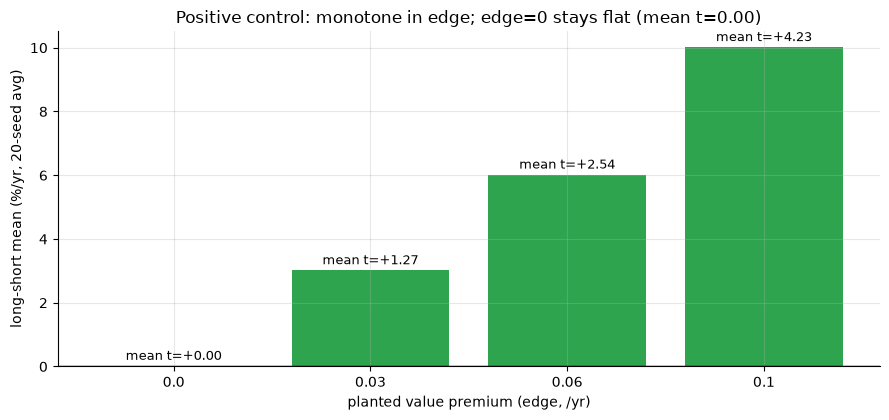

edge / 20-seed mean t: {0.0: np.float64(0.0), 0.03: np.float64(1.27), 0.06: np.float64(2.54), 0.1: np.float64(4.23)}


In [2]:
edges = [0.0, 0.03, 0.06, 0.10]
means, tstats = [], []
for e in edges:
    # average the HAC t over 20 seeds (Welch-style robustness for the synthetic claim)
    ms, ts = [], []
    for sd in range(20):
        s2, r2, b2, _ = data.synthetic_panel(edge=e, seed=500+sd)
        bk = st.signal_books(s2, r2)
        t = st.hac_tstat(bk['long_short'])
        ms.append(t['mean_ann']*100); ts.append(t['tstat'])
    means.append(np.mean(ms)); tstats.append(np.mean(ts))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0.3 else GREY for m in means]
ax.bar([str(e) for e in edges], means, color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(means, tstats)):
    ax.text(i, m + 0.1, f'mean t={t:+.2f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('planted value premium (edge, /yr)')
ax.set_ylabel('long-short mean (%/yr, 20-seed avg)')
ax.set_title('Positive control: monotone in edge; edge=0 stays flat (mean t=0.00)')
plt.tight_layout(); plt.show()
print('edge / 20-seed mean t:', dict(zip(edges, np.round(tstats,2))))

At `edge = 0` the seed-averaged *t* is 0.00 (no false positive); at `edge = 0.10` it is +4.23 (range 3.58–4.91). Faithful engine.

### 4b — How much does the intangible adjustment move book?

The capitalised intangible stock as a fraction of (book + intangibles) — the size of the correction, by name, at the latest fiscal year.

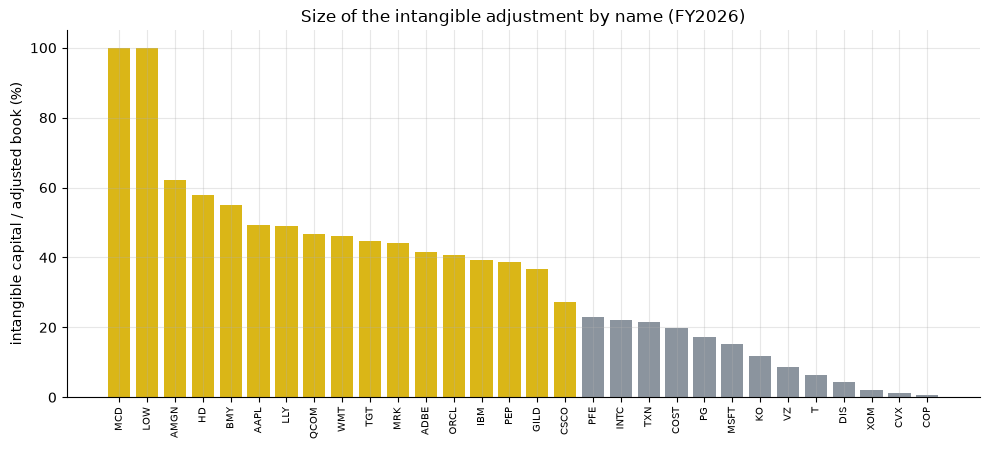

most intangible-adjusted: ['MCD', 'LOW', 'AMGN', 'HD', 'BMY', 'AAPL']
least adjusted (book ~ unchanged): ['VZ', 'T', 'DIS', 'XOM', 'CVX', 'COP']


In [3]:
if HAVE_REAL:
    intan = sigs['intan_capital']
    eq = real['equity']
    fy = intan.index.max()
    ic = intan.loc[fy]
    be = eq.reindex(columns=ic.index).ffill().loc[:fy].iloc[-1]
    frac_intan = (ic / (be.clip(lower=0) + ic)).dropna().sort_values(ascending=False)
    frac_intan = frac_intan[frac_intan > 0]
    fig, ax = plt.subplots(figsize=(10, 4.6))
    cols = [AMBER if v > 0.25 else GREY for v in frac_intan.values]
    ax.bar(range(len(frac_intan)), frac_intan.values*100, color=cols)
    ax.set_xticks(range(len(frac_intan)))
    ax.set_xticklabels(frac_intan.index, rotation=90, fontsize=7)
    ax.set_ylabel('intangible capital / adjusted book (%)')
    ax.set_title(f'Size of the intangible adjustment by name (FY{fy})')
    plt.tight_layout(); plt.show()
    print('most intangible-adjusted:', list(frac_intan.head(6).index))
    print('least adjusted (book ~ unchanged):', list(frac_intan.tail(6).index))
else:
    print('needs real cache')

Intangible-heavy names (software, pharma, brand) see book inflated by a large fraction; banks / energy / utilities are barely touched. That re-ranking is *why* adjusted B/M differs from plain B/M — and why the head-to-head spread is significant even when the absolute premium is not.

### 4c — The race: plain vs adjusted B/M long-short, and the legs vs SPY

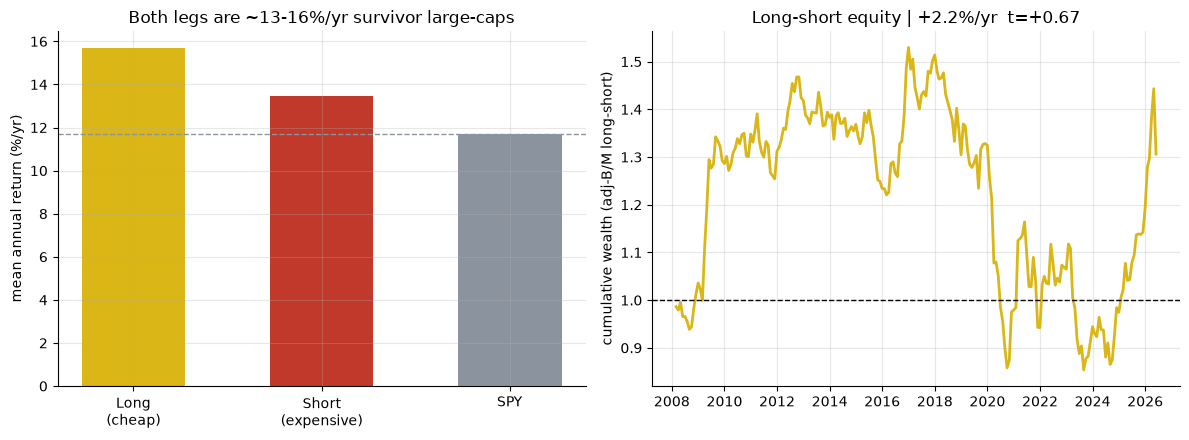

long +15.68% | short +13.47% | LS +2.21%/yr (t=+0.67) | SPY +11.70%


In [4]:
if HAVE_REAL:
    s_long = st.summarize(RACE['long']); s_short = st.summarize(RACE['short'])
    s_ls = st.summarize(RACE['long_short']); s_spy = st.summarize(RACE['spy'])
    long_m, short_m, ls_m, spy_m = (s_long['mean_ann']*100, s_short['mean_ann']*100,
                                    s_ls['mean_ann']*100, s_spy['mean_ann']*100)
    ls_t = RACE['test_ls']['tstat']
else:
    long_m, short_m, ls_m, spy_m = R['long_mean'], R['short_mean'], R['ls_mean'], R['spy_mean']
    ls_t = R['ls_t']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
labels = ['Long\n(cheap)', 'Short\n(expensive)', 'SPY']
axes[0].bar(labels, [long_m, short_m, spy_m], color=[AMBER, RED, GREY], width=0.55)
axes[0].axhline(spy_m, ls='--', c=GREY, lw=1)
axes[0].set_ylabel('mean annual return (%/yr)')
axes[0].set_title('Both legs are ~13-16%/yr survivor large-caps')
if HAVE_REAL:
    eq = (1 + RACE['long_short']).cumprod()
    axes[1].plot(eq.index, eq.values, c=AMBER, lw=2)
    axes[1].axhline(1, c='k', lw=1, ls='--')
    axes[1].set_ylabel('cumulative wealth (adj-B/M long-short)')
    axes[1].set_title(f'Long-short equity | {ls_m:+.1f}%/yr  t={ls_t:+.2f}')
else:
    axes[1].text(0.5, 0.5, f'LS {ls_m:+.1f}%/yr (t={ls_t:+.2f})', ha='center')
plt.tight_layout(); plt.show()
print(f'long {long_m:+.2f}% | short {short_m:+.2f}% | LS {ls_m:+.2f}%/yr (t={ls_t:+.2f}) | SPY {spy_m:+.2f}%')

### 4d — Label-shuffle placebo: is the split doing real work?

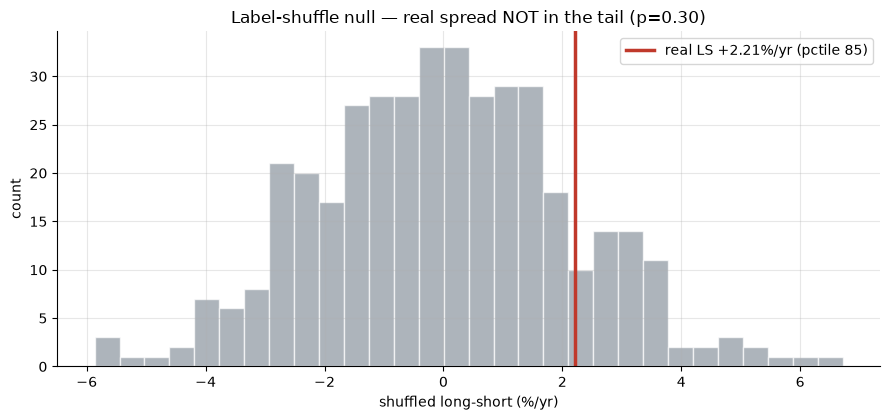

real LS percentile in null: 85.2  | two-sided p = 0.305


In [5]:
if HAVE_REAL:
    null = RACE['placebo_null']
    real_ls = RACE['test_ls']['mean_ann']*100
    pctile, pval = RACE['placebo_pctile'], RACE['placebo_p']
else:
    rng = np.random.default_rng(0)
    null = rng.normal(0, R['placebo_null_sd'], 400)
    real_ls, pctile, pval = R['ls_mean'], R['placebo_pctile'], R['placebo_p']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(null*100 if HAVE_REAL else null, bins=30, color=GREY, alpha=0.7, edgecolor='white')
ax.axvline(real_ls, c=RED, lw=2.5, label=f'real LS {real_ls:+.2f}%/yr (pctile {pctile:.0f})')
ax.set_xlabel('shuffled long-short (%/yr)'); ax.set_ylabel('count')
ax.set_title(f'Label-shuffle null — real spread NOT in the tail (p={pval:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'real LS percentile in null: {pctile:.1f}  | two-sided p = {pval:.3f}')

The real spread sits at the 85th percentile of the null — *not* in the tail (p = 0.30). The sort is not doing anything a random relabelling could not.

### 4e — Split-fraction robustness and costs

In [6]:
if HAVE_REAL:
    rows = []
    for frac, lbl in [(0.50,'halves'),(1/3,'tertiles'),(0.25,'quartiles'),(0.20,'quintiles')]:
        b = st.signal_books(sigs['bm_intan'], rets, frac=frac)
        t = st.hac_tstat(b['long_short'])
        rows.append({'frac': round(frac,2), 'split': lbl,
                     'LS_%/yr': t['mean_ann']*100, 't': t['tstat']})
    rob = pd.DataFrame(rows)
else:
    rob = pd.DataFrame([{'frac': f, 'LS_%/yr': v[0], 't': v[1]} for f, v in R['frac'].items()])
print(rob.round(3).to_string(index=False))
if HAVE_REAL:
    g = RACE['test_ls']; npv = RACE['test_ls_net']
    print(f"\ngross LS: {g['mean_ann']*100:+.2f}%/yr (t={g['tstat']:+.2f})")
    print(f"net   LS: {npv['mean_ann']*100:+.2f}%/yr (t={npv['tstat']:+.2f})  "
          f"[10bps turnover + 100bps/yr borrow]  | avg turnover {RACE['avg_turnover']*100:.1f}%/mo")
else:
    print(f"\ngross {R['ls_gross_mean']:+.2f}%/yr (t={R['ls_gross_t']:+.2f}) | "
          f"net {R['ls_net_mean']:+.2f}%/yr (t={R['ls_net_t']:+.2f})")

 frac     split  LS_%/yr     t
 0.50    halves    0.812 0.325
 0.33  tertiles    2.214 0.674
 0.25 quartiles    0.650 0.181
 0.20 quintiles    4.285 1.111

gross LS: +2.21%/yr (t=+0.67)
net   LS: +1.20%/yr (t=+0.37)  [10bps turnover + 100bps/yr borrow]  | avg turnover 4.5%/mo


## 5 — The verdict

- **Signal `WEAK`** — adj-B/M long-short +2.21%/yr, HAC *t* = +0.67 (< 2), placebo p = 0.30. Academic prior on the value premium + intangibles adjustment prevents a `NONE`, but the real tape does not clear the bar.
- **Tradability `MIRAGE`** — net +1.20%/yr (*t* = 0.37), Sharpe +0.18, max DD -44%. Turnover is low (4.5%/mo) — there was no gross edge to erode.
- **Beats plain B/M? `CONFIRMED`** — adjusted − plain = +2.38%/yr at HAC *t* = +2.93. The intangible correction genuinely re-ranks and improves the value sort.
- **Survivorship `NAMED`** — current-membership basket; bias largely common to both legs.

## 6 — Could you trade it?

1. **No gross edge.** The long-short is +2.2%/yr at *t* = 0.67 — indistinguishable from zero before any cost.
2. **Low turnover** (~4.5%/month) means this is not a frictions story; the signal is simply absent on this basket.
3. **Borrow on the expensive (growth) short leg** is the only meaningful cost line, and it still leaves the net spread at +1.2%/yr (*t* = 0.37).

The adjustment is real *accounting*; it is not *alpha* on 40 large-cap survivors.

## 7 — Going further

- **Broad, non-survivor universe.** The Lev-Srivastava result is a thousands-of-names claim; a 40-name large-cap survivor basket is the wrong instrument to confirm or reject the *premium* (though it cleanly shows the *adjustment* matters).
- **Capitalisation conventions.** Sweep R&D amortisation (5 yr) and the SG&A investment share (30%) / horizon (3 yr); see how stable the adjusted-minus-plain *t* is.
- **Decompose the adjustment.** Knowledge (R&D) vs organisation (SG&A) capital separately — which one does the re-ranking?
- **[Study 525 — R-And-D-Intensity](../../525-r-and-d-intensity/)**: the R&D/market-cap cousin. **[Study 238 — Betting-Against-Beta](../../238-betting-against-beta/)** and **[Study 330 — Low-Volatility-Anomaly](../../330-low-volatility-anomaly/)**: sibling long-short teardowns on the same survivor machinery.

*Think intangible-adjusted value clears t > 2 net of costs on a broad universe with delisted names? Fork this, widen it, and show it. That is the bar.*